# Clustering Analysis Assignment

## K-Means, Hierarchical & DBSCAN Clustering

In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage


In [2]:
# Load Dataset

df = pd.read_excel('EastWestAirlines.xlsx')

df.head()


,East-West Airlines is trying to learn more about its customers. Key issues are their,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,"flying patterns, earning and use of frequent f...",NaN,NaN,NaN,NaN
1,card. The task is to identify customer segmen...,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN
4,Source: Based upon real business data; company...,NaN,NaN,NaN,NaN


In [3]:
# Dataset Information

df.info()
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 5 columns):
 #   Column                                                                                 Non-Null Count  Dtype 
---  ------                                                                                 --------------  ----- 
 0   East-West Airlines is trying to learn more about its customers.  Key issues are their  18 non-null     str   
 1   Unnamed: 1                                                                             13 non-null     str   
 2   Unnamed: 2                                                                             6 non-null      object
 3   Unnamed: 3                                                                             13 non-null     str   
 4   Unnamed: 4                                                                             18 non-null     str   
dtypes: object(1), str(4)
memory usage: 1.1+ KB


,East-West Airlines is trying to learn more about its customers. Key issues are their,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4
count,18,13,6,13,18
unique,18,3,3,3,18
top,"flying patterns, earning and use of frequent f...",NUMBER,1,Raw,Description
freq,1,9,3,9,1


In [4]:
# Check Missing Values

df.isnull().sum()


East-West Airlines is trying to learn more about its customers.  Key issues are their     8
Unnamed: 1                                                                               13
Unnamed: 2                                                                               20
Unnamed: 3                                                                               13
Unnamed: 4                                                                                8
dtype: int64

In [5]:
# Select Only Numeric Columns

numeric_df = df.select_dtypes(include=['number'])

numeric_df.head()


""
0
1
2
3
4


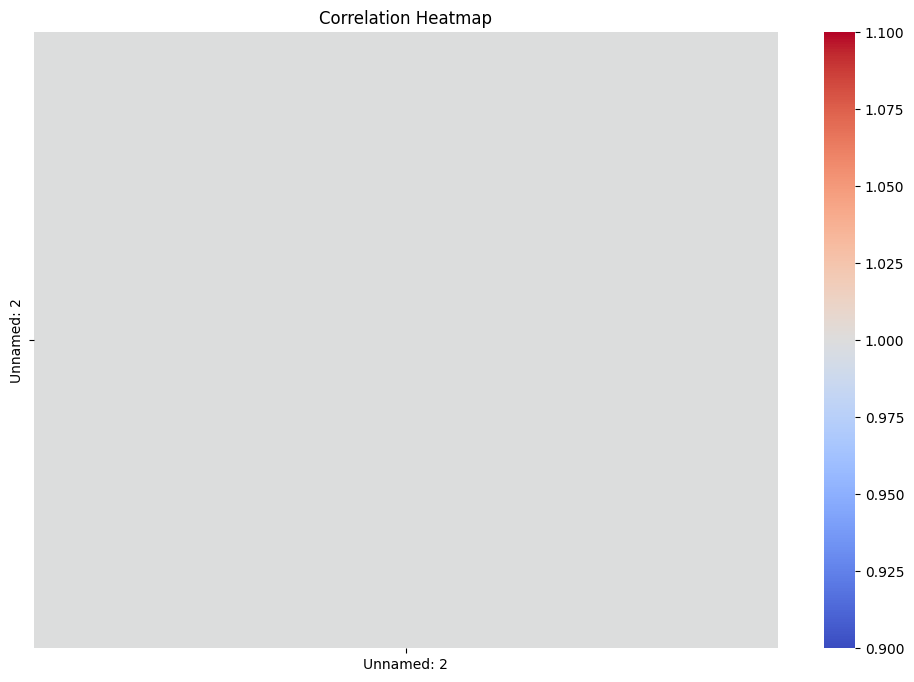

In [12]:
# Convert columns to numeric if possible

for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Remove fully empty columns
numeric_df = df.dropna(axis=1, how='all')

# Correlation Heatmap

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    cmap='coolwarm',
    annot=False
)

plt.title('Correlation Heatmap')

plt.show()

In [17]:
# Feature Scaling

# Fill missing values
numeric_df = numeric_df.fillna(numeric_df.mean())

# Standard Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(numeric_df)

# Create DataFrame
scaled_df = pd.DataFrame(
    scaled_data,
    columns=numeric_df.columns
)

scaled_df.head()

,Unnamed: 2
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0


In [18]:
# Handle Missing Values

numeric_df = numeric_df.fillna(numeric_df.mean())

# Apply K-Means Clustering

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(scaled_df)

scaled_df['KMeans_Cluster'] = kmeans_labels

# Silhouette Score

kmeans_score = silhouette_score(
    scaled_df.drop('KMeans_Cluster', axis=1),
    kmeans_labels
)

print("K-Means Silhouette Score:", kmeans_score)

K-Means Silhouette Score: 1.0


In [19]:
# KMeans Clustering

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

labels = kmeans.fit_predict(scaled_df)

scaled_df['KMeans_Cluster'] = labels

score = silhouette_score(
    scaled_df.drop('KMeans_Cluster', axis=1),
    labels
)

print('KMeans Silhouette Score:', score)


KMeans Silhouette Score: 1.0


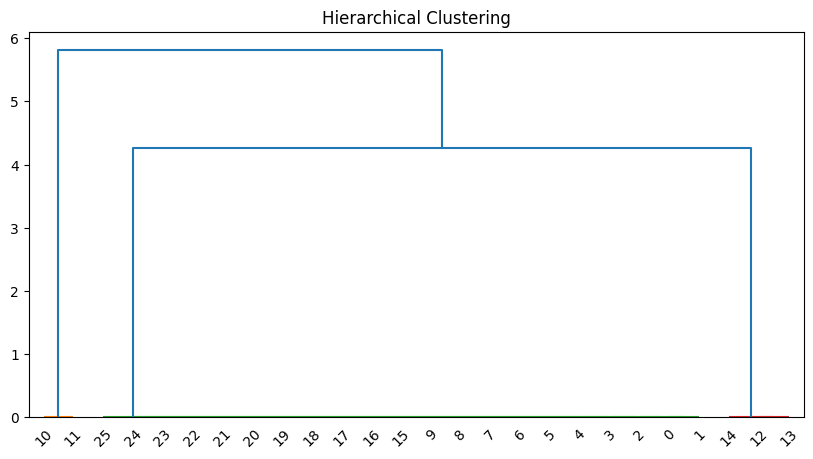

In [20]:
# Hierarchical Clustering

linked = linkage(
    scaled_df.drop('KMeans_Cluster', axis=1),
    method='ward'
)

plt.figure(figsize=(10,5))

dendrogram(linked)

plt.title('Hierarchical Clustering')

plt.show()


In [21]:
# Agglomerative Clustering

hc = AgglomerativeClustering(n_clusters=3)

hc_labels = hc.fit_predict(
    scaled_df.drop('KMeans_Cluster', axis=1)
)

scaled_df['HC_Cluster'] = hc_labels

hc_score = silhouette_score(
    scaled_df.drop(['KMeans_Cluster','HC_Cluster'], axis=1),
    hc_labels
)

print('Hierarchical Silhouette Score:', hc_score)


Hierarchical Silhouette Score: 1.0


In [22]:
# DBSCAN Clustering

db = DBSCAN(eps=2, min_samples=5)

db_labels = db.fit_predict(
    scaled_df.drop(['KMeans_Cluster','HC_Cluster'], axis=1)
)

scaled_df['DBSCAN_Cluster'] = db_labels

if len(set(db_labels)) > 1:

    db_score = silhouette_score(
        scaled_df.drop(
            ['KMeans_Cluster','HC_Cluster','DBSCAN_Cluster'],
            axis=1
        ),
        db_labels
    )

    print('DBSCAN Silhouette Score:', db_score)

else:

    print('DBSCAN could not form meaningful clusters')


DBSCAN Silhouette Score: 0.8876254180602008


In [ ]:
import pandas as pd

df = pd.read_excel('wine.xlsx', sheet_name=1)

print("Dataset Loaded Successfully from Sheet2")
print(df.head())


In [ ]:
# K-Means Experiments with Different K Values

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_values = [2,3,4,5,6]

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    print(f"K = {k} -> Silhouette Score = {score}")


In [ ]:
# Hierarchical Clustering Experiments

from sklearn.cluster import AgglomerativeClustering

linkages = ['ward', 'complete', 'average']

for linkage in linkages:

    hc = AgglomerativeClustering(
        n_clusters=3,
        linkage=linkage
    )

    labels = hc.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    print(f"Linkage = {linkage} -> Silhouette Score = {score}")


In [ ]:
# DBSCAN Experiments

from sklearn.cluster import DBSCAN

eps_values = [0.3, 0.5, 0.7]

for eps in eps_values:

    db = DBSCAN(eps=eps, min_samples=5)

    labels = db.fit_predict(X_scaled)

    unique_clusters = len(set(labels))

    print(f"EPS = {eps} -> Clusters Found = {unique_clusters}")
